# Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
df = pd.read_csv("../data/mesures_capteurs.csv", parse_dates=["date_heure"])
df

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
...,...,...,...,...,...,...,...,...,...
600,M0072,2026-01-07 23:00:00,C012,B004,23.67,60.28,1015.11,282.36,OK
601,M0107,2026-01-09 10:00:00,C011,B004,24.34,61.42,1019.43,357.43,OK
602,M0271,2026-01-16 06:00:00,C007,B003,23.73,63.49,1016.46,152.79,OK
603,M0436,2026-01-23 03:00:00,C004,B002,24.83,79.77,1017.05,170.97,OK


# Partie 1 – Distribution d'une variable avec histplot()

## 1) Afficher la distribution des températures

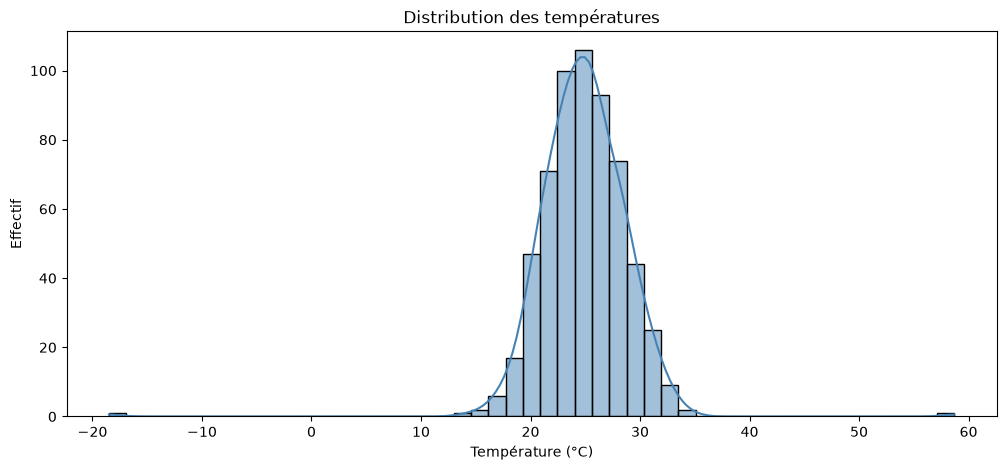

In [51]:
plt.subplots(figsize=(12,5))
sns.histplot(df, x="temperature", color="steelblue", kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Effectif")
plt.show()

## 2) Autour de quelle valeur les températures sont concentrées ?

In [52]:
print("Moyenne :", df["temperature"].mean().round(2))
print("Médiane :", df["temperature"].median().round(2))

Moyenne : 24.88
Médiane : 24.86


les temperatures sont concentrees au tour de la moyenne 24, 88

## 3) La distribution semble-t-elle symétrique ?

Oui, Car la moyenne et sensiblement egale a la mediane

## 4) Existe-t-il des valeurs extrêmes ?

In [53]:
q1, q3 = df["temperature"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["temperature"] < lower) | (df["temperature"] > upper)]
print(f"Bornes IQR : [{lower:.2f}, {upper:.2f}]")
print(f"Nombre de valeurs extrêmes : {len(outliers)}")
outliers[["id_mesure", "batiment", "temperature"]]

Bornes IQR : [15.51, 34.33]
Nombre de valeurs extrêmes : 5


,id_mesure,batiment,temperature
43,M0575,B004,34.72
245,M0127,B003,14.11
258,M0223,B003,15.49
487,M0538,B004,-18.50
502,M0048,B004,58.70


Oui, on a 5 valeurs aberant

## 5) Modifier le nombre de classes

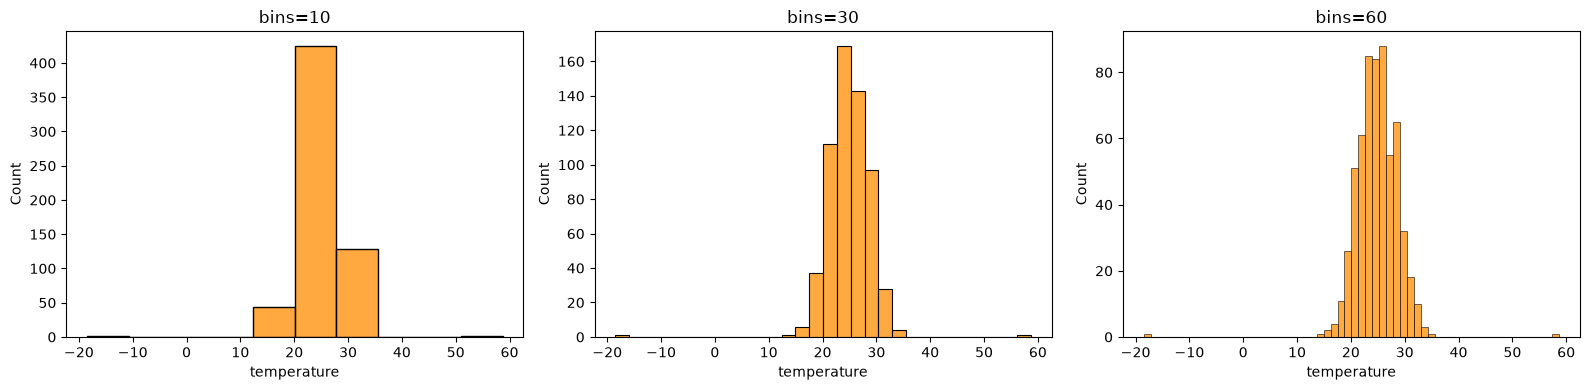

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, b in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=b, ax=ax, color="darkorange")
    ax.set_title(f"bins={b}")
plt.tight_layout()
plt.show()

## 6) Afficher la distribution des températures par bâtiment

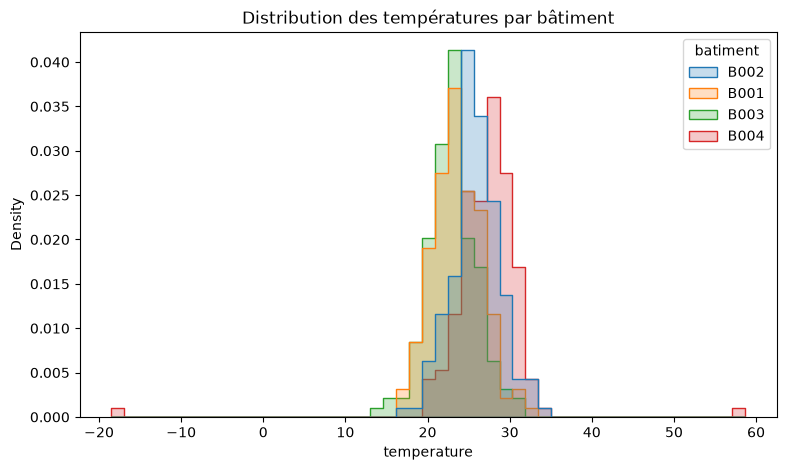

In [55]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", element="step", stat="density")
plt.title("Distribution des températures par bâtiment")
plt.show()

## Partie 2 – Distribution d'une variable avec kdeplot()

## 1) Afficher la distribution des températures

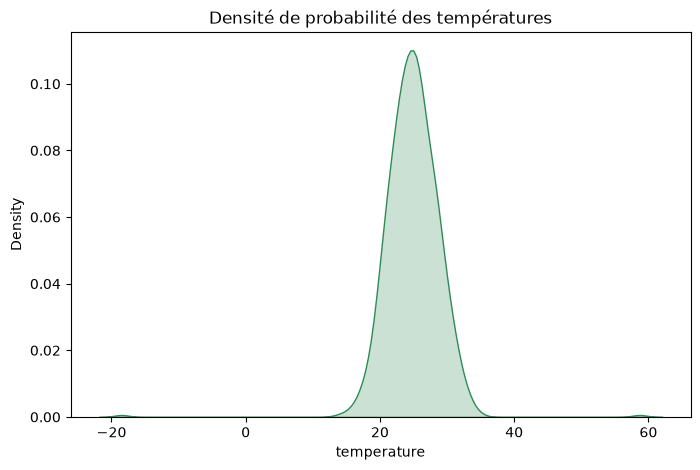

In [56]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True, color="seagreen")
plt.title("Densité de probabilité des températures")
plt.show()

## 2) Afficher la distribution des températures par bâtiment

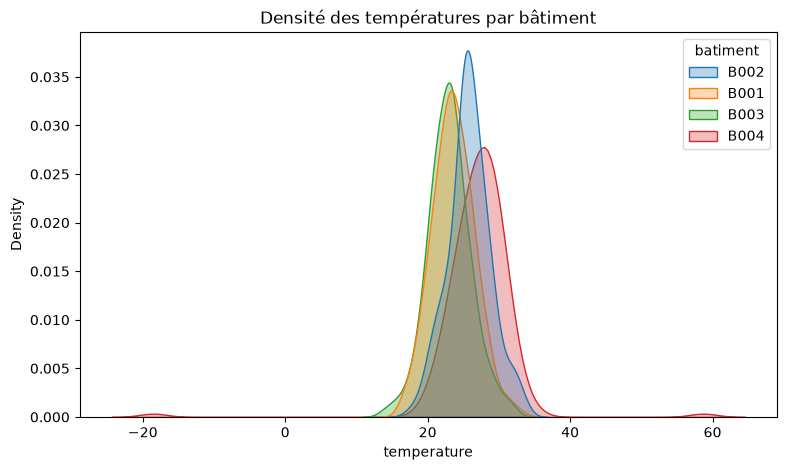

In [57]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.show()

# Partie 3 – Distribution d'une variable avec boxplot()

## 1) Afficher la distribution des températures

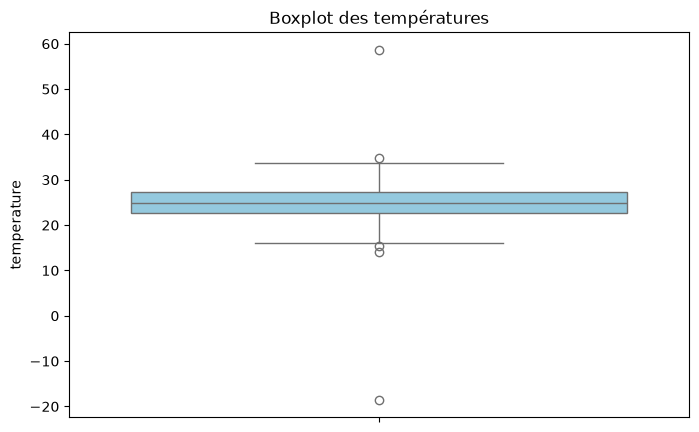

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="temperature", color="skyblue")
plt.title("Boxplot des températures")
plt.show()

## 2) Afficher la distribution des températures par bâtiment

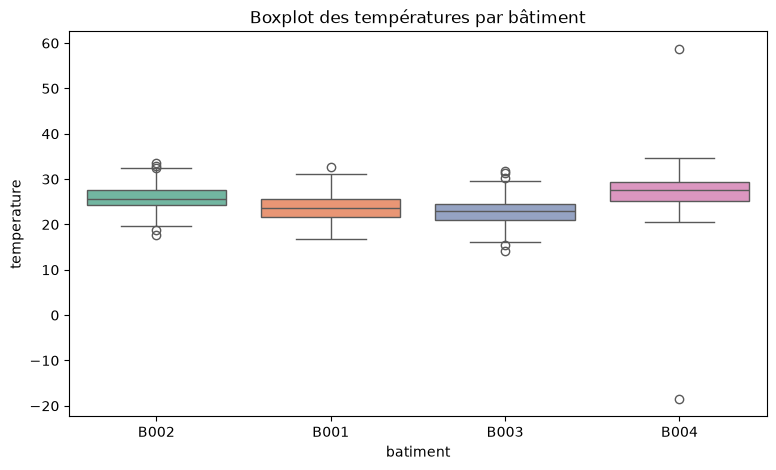

In [59]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set2", legend=False)
plt.title("Boxplot des températures par bâtiment")
plt.show()

## 3) Pour chaque bâtiment,
### a) quelle est la médiane ?
### b) quelle est la dispersion ?
### c) les valeurs extrêmes

In [60]:
summary = df.groupby("batiment")["temperature"].describe()[["50%", "25%", "75%", "min", "max"]]
summary["IQR"] = summary["75%"] - summary["25%"]
summary

,50%,25%,75%,min,max,IQR
batiment,,,,,,
B001,23.540,21.6100,25.6700,16.77,32.72,4.0600
B002,25.670,24.2675,27.5300,17.67,33.60,3.2625
B003,23.045,21.0825,24.5950,14.11,31.74,3.5125
B004,27.535,25.1750,29.2825,-18.50,58.70,4.1075


## 4) quels bâtiments ont les valeurs les plus extrêmes ?

C'est le batiment B004 on peut remarquer dans le graphe comme aussi dans min et max

# Partie 4 – Distribution d'une variable avec violinplot()

## 1) Afficher la distribution des températures


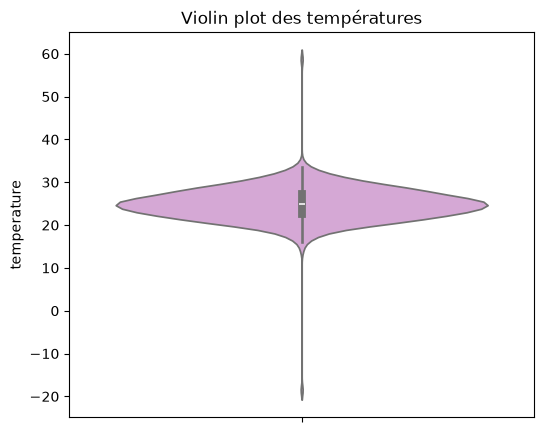

In [61]:
plt.figure(figsize=(6, 5))
sns.violinplot(data=df, y="temperature", color="plum")
plt.title("Violin plot des températures")
plt.show()

## 2) Afficher la distribution des températures par bâtiment

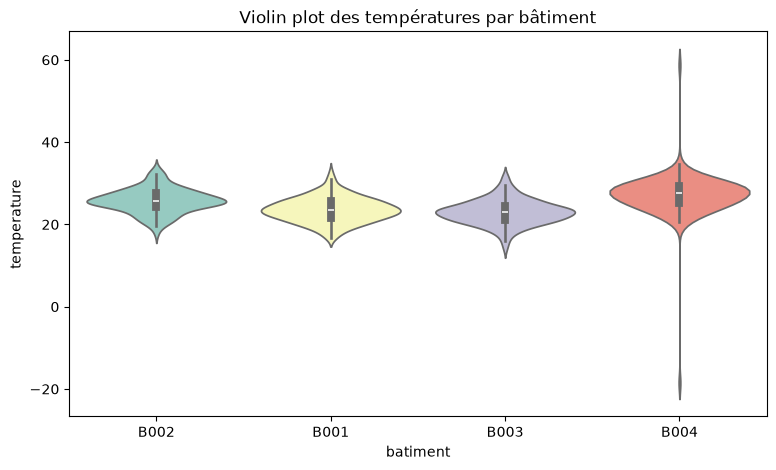

In [62]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set3", legend=False)
plt.title("Violin plot des températures par bâtiment")
plt.show()

## 3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ?

Le violin plot ajoute la forme de la densité (KDE) autour de la boîte, ce qui permet de voir si la distribution est unimodale, bimodale, étalée ou concentrée information invisible sur un simple boxplot.

# Partie 5 – Comptage des catégories avec countplot()

## 1) Afficher le nombre de mesures par état

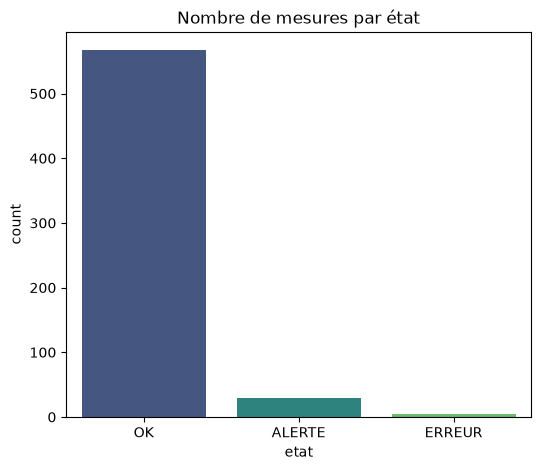

In [63]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="etat", hue="etat", palette="viridis", legend=False)
plt.title("Nombre de mesures par état")
plt.show()

## 2) Afficher le nombre de mesures par bâtiment

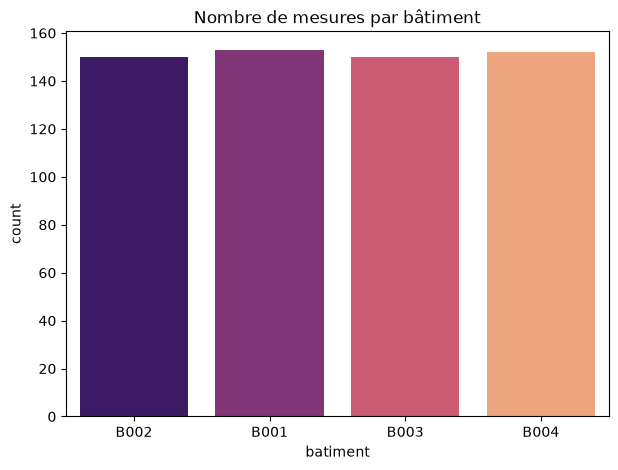

In [64]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="batiment", hue="batiment", palette="magma", legend=False)
plt.title("Nombre de mesures par bâtiment")
plt.show()

## 3) Afficher les états des capteurs par bâtiment pour identifier.

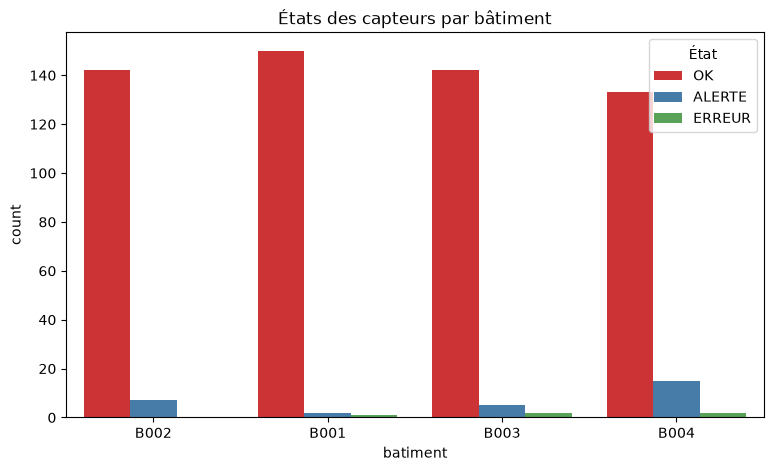

In [65]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="batiment", hue="etat", palette="Set1")
plt.title("États des capteurs par bâtiment")
plt.legend(title="État")
plt.show()

In [66]:
etat_batiment = df.groupby(["batiment", "etat"]).size().unstack(fill_value=0)
etat_batiment

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


### a) le bâtiment ayant le plus de mesures en état OK ;


D'apres le graphe c'est le batiment B001

### b) celui ayant le plus de mesures en ALERTE ;


D'apres le graphe c'est le batiment B004

### c) celui ayant le plus de mesures en ERREUR

D'apres le graphe c'est le batiment B003 et B004